## 1) Title and goals
MNIST is a dataset of 70,000 grayscale images of handwritten digits (0-9). Each image is 28x28 pixels, so every sample is a small grid of pixel intensities.

In this notebook, we explore data quality, class balance, visual variation, and low-dimensional structure. The goal is to build intuition about what models should find easy or difficult before we train anything.


## 2) Imports and reproducibility
We keep dependencies minimal and fix random seeds so the sampling steps are repeatable.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import tensorflow as tf

# Fix numpy's random seed to 42 for reproducible results
# This ensures that any random sampling will produce the same results each time
np.random.seed(42)
# Fix tensorflow's random seed to 42 for reproducible results
# This affects any random operations in tensorflow functions
tf.random.set_seed(42)

# Set default figure size to 8 inches wide by 5 inches tall
# This makes all plots consistently sized without specifying each time
plt.rcParams["figure.figsize"] = (8, 5)
# Set default colormap to grayscale for displaying images
# "gray" colormap shows 0 as black and 1 as white, ideal for handwritten digits
plt.rcParams["image.cmap"] = "gray"

# Create a new random number generator with seed 42
# Using default_rng is the modern numpy approach for random operations
# This RNG will be used for reproducible subsampling throughout the notebook
rng = np.random.default_rng(42)


## 3) Load dataset and basic checks
We load MNIST and confirm shapes, dtypes, and value ranges before any transformations.


In [ ]:
from tensorflow.keras.datasets import mnist

# Load the MNIST dataset
# Returns two tuples: (training data, training labels), (test data, test labels)
# x_train: 60,000 training images of shape (28, 28)
# y_train: 60,000 training labels (integers 0-9)
# x_test: 10,000 test images of shape (28, 28)
# y_test: 10,000 test labels (integers 0-9)
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Print shape and data type information for all arrays
# shape gives the dimensions: (number of samples, height, width)
# dtype gives the data type (typically uint8 for raw images, meaning 0-255 integers)
print("x_train:", x_train.shape, x_train.dtype)
print("y_train:", y_train.shape, y_train.dtype)
print("x_test:", x_test.shape, x_test.dtype)
print("y_test:", y_test.shape, y_test.dtype)

# Check the minimum and maximum pixel values
# For uint8 images, min=0 (black) and max=255 (white)
# .min() finds the smallest pixel value across all training images
# .max() finds the largest pixel value across all training images
print("x_train min/max:", x_train.min(), x_train.max())
print("x_test min/max:", x_test.min(), x_test.max())

# Normalize pixel values from [0, 255] to [0.0, 1.0]
# .astype(np.float32) converts from uint8 integers to 32-bit floating point
# Dividing by 255.0 scales the values to the [0, 1] range
# This normalization helps with:
#   1) Stable numerical operations (distances, PCA)
#   2) Better gradient flow in neural networks
#   3) Consistent scale across features
x_train_norm = x_train.astype(np.float32) / 255.0
x_test_norm = x_test.astype(np.float32) / 255.0


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train: (60000, 28, 28) uint8
y_train: (60000,) uint8
x_test: (10000, 28, 28) uint8
y_test: (10000,) uint8
x_train min/max: 0 255
x_test min/max: 0 255


## 4) Class distribution
We count how many examples of each digit appear in the training data.


Digit 0: 5923 (0.099)
Digit 1: 6742 (0.112)
Digit 2: 5958 (0.099)
Digit 3: 6131 (0.102)
Digit 4: 5842 (0.097)
Digit 5: 5421 (0.090)
Digit 6: 5918 (0.099)
Digit 7: 6265 (0.104)
Digit 8: 5851 (0.098)
Digit 9: 5949 (0.099)


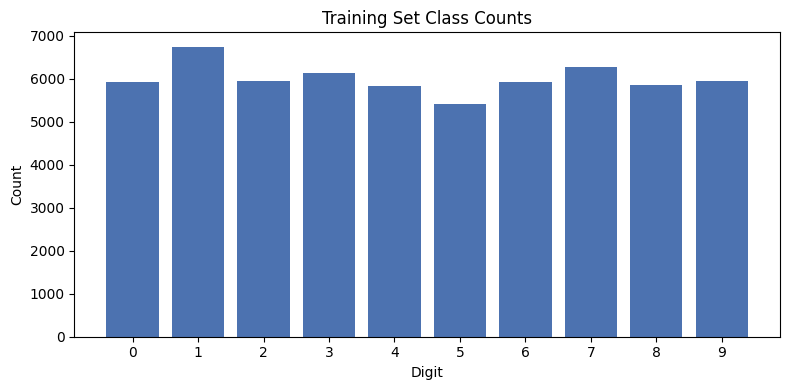

In [ ]:
# Count how many times each digit (0-9) appears in the training set
# np.bincount counts occurrences of each integer value in the array
# minlength=10 ensures we get counts for all 10 digits (0-9) even if some are missing
counts = np.bincount(y_train, minlength=10)
# Calculate the proportion of each digit by dividing by total count
# This tells us what fraction of the dataset each digit represents
proportions = counts / counts.sum()

# Print the count and proportion for each digit
# This helps us identify any class imbalance issues
for digit in range(10):
    print(f"Digit {digit}: {counts[digit]} ({proportions[digit]:.3f})")

# Create a bar chart to visualize the class distribution
# figsize=(8, 4) sets the figure to 8 inches wide by 4 inches tall
fig, ax = plt.subplots(figsize=(8, 4))
# Create bars at positions 0-9 with heights equal to counts
# color="#4c72b0" is a pleasant blue color
# np.arange(10) creates positions [0, 1, 2, ..., 9] for the bars
ax.bar(np.arange(10), counts, color="#4c72b0")
# Set the title that appears above the chart
ax.set_title("Training Set Class Counts")
# Label the x-axis (horizontal axis)
ax.set_xlabel("Digit")
# Label the y-axis (vertical axis)
ax.set_ylabel("Count")
# Ensure x-axis shows tick marks at 0, 1, 2, ..., 9
ax.set_xticks(np.arange(10))
# Adjust subplot parameters to prevent labels from being cut off
plt.tight_layout()
# Display the plot
plt.show()


The class counts are close to even, which means we do not have a major class imbalance problem. Class balance matters because an imbalanced dataset can make a model look accurate while it ignores rare digits. With roughly similar counts, accuracy and macro-averaged metrics are more reliable.


## 5) Visual gallery by class
A grid of examples makes the range of handwriting styles easy to see.


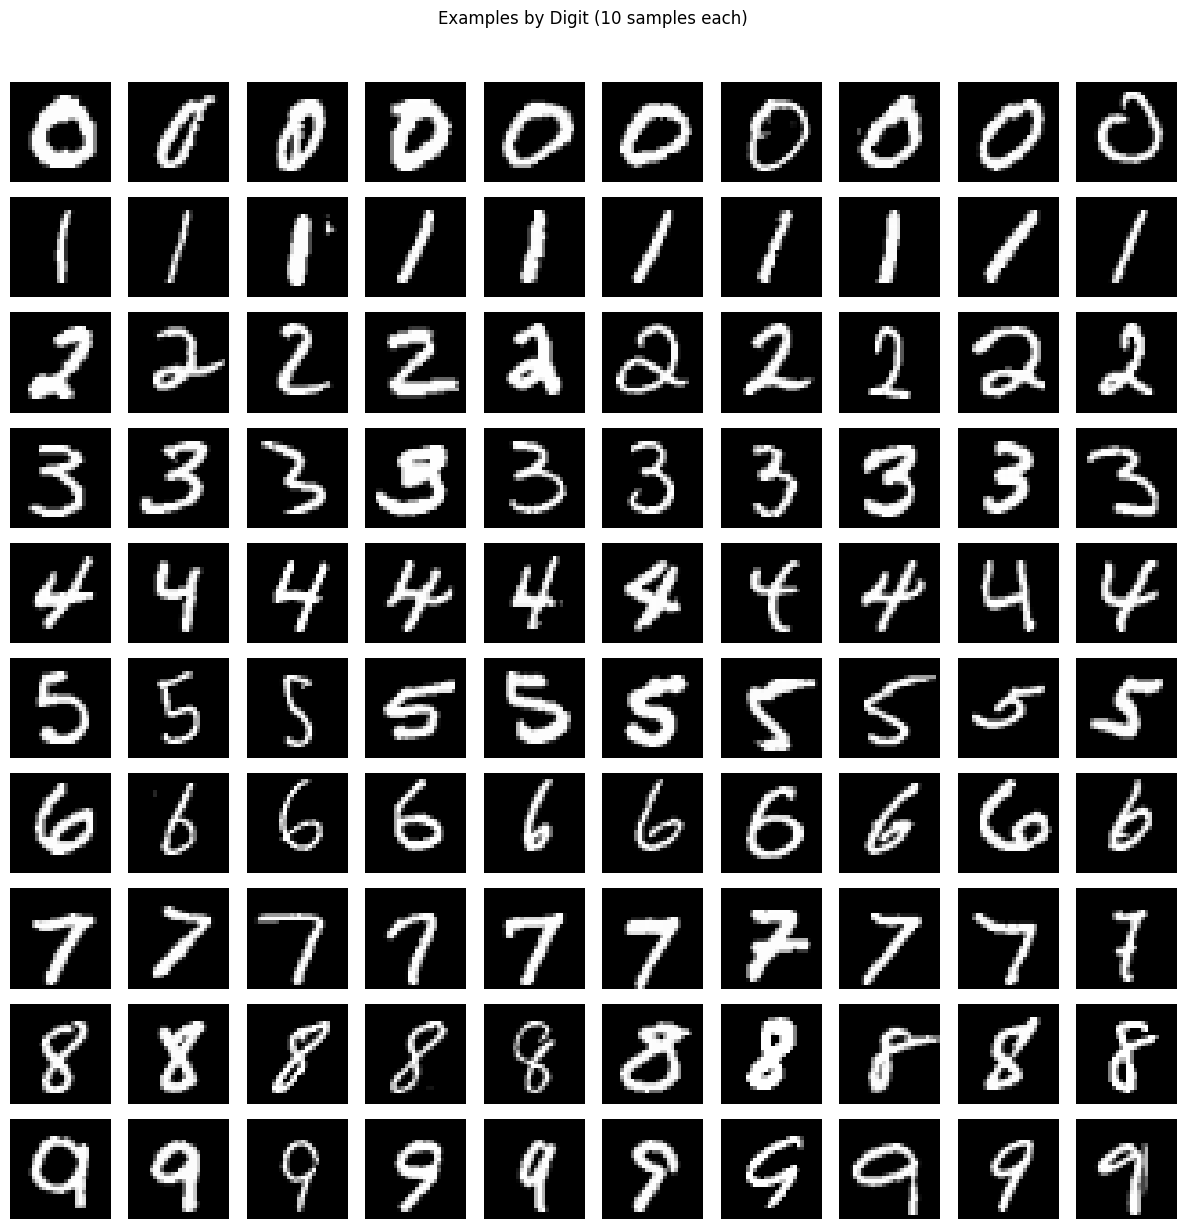

In [ ]:
# Set how many example images to show for each digit
samples_per_class = 10
# Create a grid of subplots: 10 rows (one per digit) × 10 columns (samples)
# figsize is calculated to give each image about 1.2 inches width and the grid 12 inches height
fig, axes = plt.subplots(10, samples_per_class, figsize=(samples_per_class * 1.2, 12))

# Loop through each digit (0-9) to populate each row
for digit in range(10):
    # Find all indices in the training set where the label equals this digit
    # np.where returns a tuple, so [0] extracts the array of indices
    class_idx = np.where(y_train == digit)[0]
    # Randomly select 10 indices from this digit's examples
    # size=samples_per_class specifies how many to choose
    # replace=False ensures we don't pick the same image twice
    chosen = rng.choice(class_idx, size=samples_per_class, replace=False)
    # Loop through each chosen index and display the corresponding image
    for j, idx in enumerate(chosen):
        # Get the subplot at row=digit, column=j
        ax = axes[digit, j]
        # Display the normalized image using grayscale colormap
        # x_train_norm[idx] retrieves the image at the chosen index
        ax.imshow(x_train_norm[idx], cmap="gray")
        # Turn off axis ticks and labels for a cleaner look
        ax.axis("off")
        # For the first image in each row (j == 0), add a label showing the digit
        if j == 0:
            # rotation=0 keeps the label horizontal (not rotated)
            # labelpad=14 adds space between the label and the plot
            # fontsize=12 sets the text size
            ax.set_ylabel(str(digit), rotation=0, labelpad=14, fontsize=12)

# Add a title above the entire figure
# y=1.02 positions it slightly above the top row to prevent overlap
fig.suptitle("Examples by Digit (10 samples each)", y=1.02)
# Adjust spacing to prevent subplot overlap
plt.tight_layout()
# Display the complete figure
plt.show()


Within each digit, there is noticeable variation in stroke thickness, slant, and how complete the shapes are. Some digits are visually similar in certain handwriting styles, such as 4 vs 9, 3 vs 5, and 1 vs 7. This overlap hints at where a classifier might confuse labels.


## 6) Mean image per class
The mean image shows the typical stroke placement for each digit.


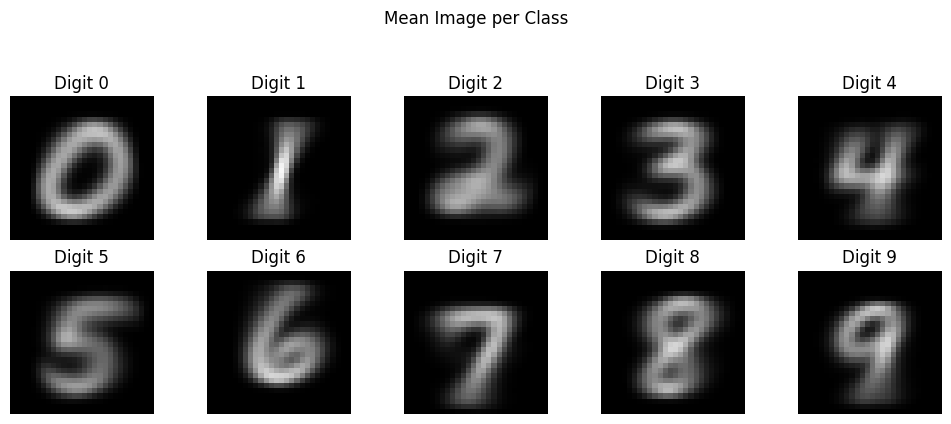

In [ ]:
# Create an array to store the mean image for each of the 10 digits
# Shape (10, 28, 28) means 10 images, each 28×28 pixels
# dtype=np.float32 uses 32-bit floats for precision
mean_images = np.zeros((10, 28, 28), dtype=np.float32)
# Calculate the average image for each digit
for digit in range(10):
    # Select all training images where y_train equals this digit
    # .mean(axis=0) computes the mean across all images (axis 0)
    # This averages corresponding pixels: result is a single 28×28 image
    mean_images[digit] = x_train_norm[y_train == digit].mean(axis=0)

# Create a 2×5 grid of subplots to display all 10 mean images
# figsize=(10, 4) makes the figure 10 inches wide and 4 inches tall
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
# Loop through each digit and its corresponding subplot
# axes.flatten() converts the 2D array of axes into a 1D list for easy iteration
for digit, ax in enumerate(axes.flatten()):
    # Display the mean image for this digit
    # vmin=0 and vmax=1 set the color scale range explicitly
    # This ensures consistent brightness across all subplots
    ax.imshow(mean_images[digit], cmap="gray", vmin=0, vmax=1)
    # Add a title showing which digit this represents
    ax.set_title(f"Digit {digit}")
    # Hide axis ticks and labels for cleaner appearance
    ax.axis("off")

# Add an overall title for the entire figure
# y=1.05 positions it above the subplots with some spacing
fig.suptitle("Mean Image per Class", y=1.05)
# Adjust layout to prevent overlapping elements
plt.tight_layout()
# Render the figure
plt.show()


The mean images highlight where each digit is usually drawn. Darker regions show where pixels are consistently active, while lighter regions show where strokes vary. This gives a simple visual summary of the core shapes the model needs to learn.


## 7) Variability (standard deviation) per class
Standard deviation highlights which parts of each digit vary the most.


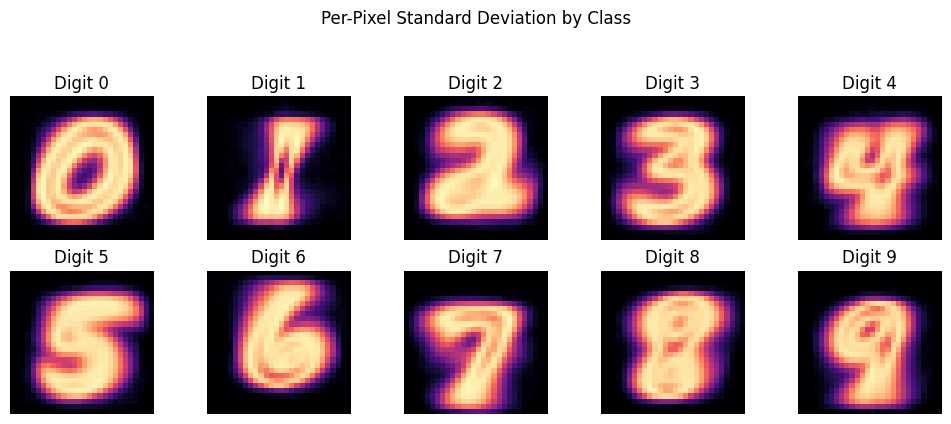

In [ ]:
# Create an array to store the standard deviation image for each digit
# Standard deviation measures how much pixel values vary from the mean
std_images = np.zeros((10, 28, 28), dtype=np.float32)
# Calculate per-pixel standard deviation for each digit class
for digit in range(10):
    # Select all images of this digit and compute std across samples (axis=0)
    # High std means that pixel varies a lot across different handwriting styles
    # Low std means that pixel is consistently on or consistently off
    std_images[digit] = x_train_norm[y_train == digit].std(axis=0)

# Find the maximum standard deviation value across all digits
# This will be used to normalize the color scale across all subplots
max_std = std_images.max()
# Create a 2×5 grid to display standard deviation for all 10 digits
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digit, ax in enumerate(axes.flatten()):
    # Display the standard deviation image using the "magma" colormap
    # magma is a perceptually uniform colormap: dark purple (low) to bright yellow (high)
    # vmin=0 sets the minimum value (darkest color)
    # vmax=max_std sets the maximum value (brightest color) consistent across all plots
    ax.imshow(std_images[digit], cmap="magma", vmin=0, vmax=max_std)
    # Label each subplot with its digit
    ax.set_title(f"Digit {digit}")
    # Remove axis decorations for cleaner visualization
    ax.axis("off")

# Add a descriptive title for the entire figure
fig.suptitle("Per-Pixel Standard Deviation by Class", y=1.05)
# Optimize spacing between subplots
plt.tight_layout()
# Display the figure
plt.show()


High-variability regions tend to be at stroke endpoints and curved sections where writers differ the most. These are the places that produce ambiguous examples, which makes classification harder. Stable regions (low variability) provide the most reliable signal for distinguishing digits.


## 8) Global pixel intensity distribution and sparsity
We check how pixel values are distributed and how much of each image is near-zero background.


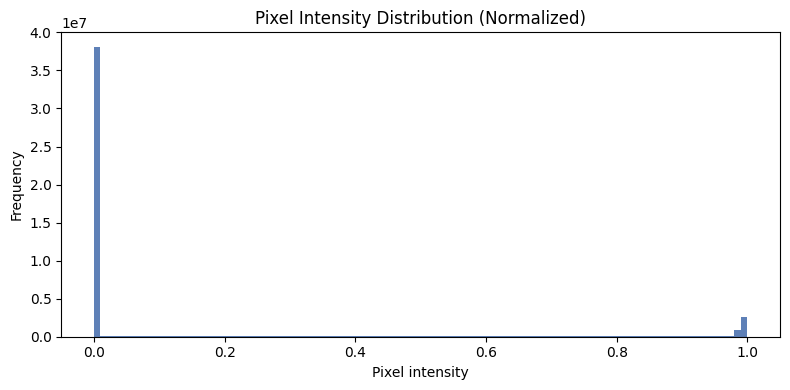

Fraction of pixels < 0.05: 0.818


In [12]:
# Flatten all training images into a single 1D array of pixel values
# Original shape: (60000, 28, 28) → flattened to (60000 * 28 * 28,) = 47,040,000 pixels
# This lets us analyze the distribution of all pixel intensities together
flat_pixels = x_train_norm.reshape(-1)

# Create a histogram to visualize pixel intensity distribution
fig, ax = plt.subplots(figsize=(8, 4))
# Plot histogram with 50 bins to divide the [0, 1] range into 50 intervals
# bins=50 creates 50 equal-width bins
# color="#4c72b0" sets a blue color
# alpha=0.9 makes the bars slightly transparent (0=invisible, 1=opaque)
ax.hist(flat_pixels, bins=100, color="#4c72b0", alpha=0.9)
# Add descriptive labels
ax.set_title("Pixel Intensity Distribution (Normalized)")
# x-axis represents pixel intensity values (0.0 to 1.0)
ax.set_xlabel("Pixel intensity")
# y-axis represents how many pixels have each intensity value
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

# Calculate what fraction of pixels are nearly black (background)
# (flat_pixels < 0.05) creates a boolean array: True where pixel < 0.05
# .mean() treats True as 1 and False as 0, giving the fraction of True values
# This quantifies the sparsity: high value means most pixels are background
sparse_fraction = (flat_pixels < 0.05).mean()
print(f"Fraction of pixels < 0.05: {sparse_fraction:.3f}")


Most pixels are close to zero, which confirms that the background is mostly empty. This sparsity matters because models can often focus on a small subset of active pixels instead of the full 28x28 grid. It also explains why simple linear models can already perform well: the signal is concentrated in predictable regions.


## 9) Alignment / centering check using center-of-mass
We measure where the "center of ink" falls to see how well digits are centered.


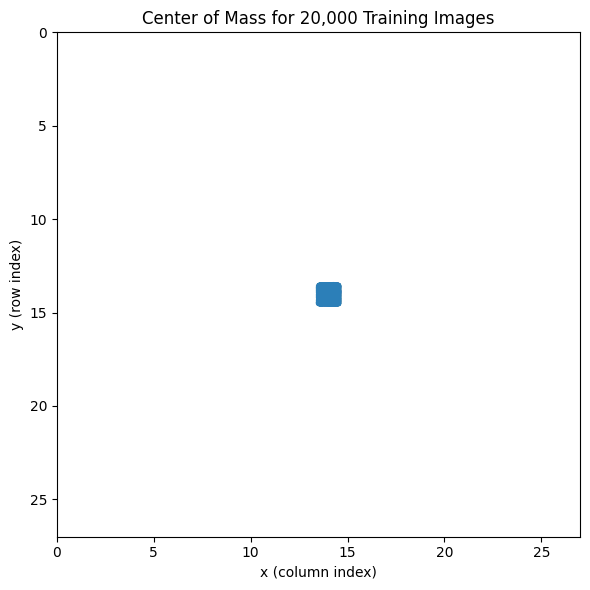

In [8]:
# Use a subset of 20,000 images to speed up computation
# Analyzing all 60,000 would be slower without much additional insight
subset_size = 20000
# Randomly select 20,000 indices without replacement
# replace=False ensures each image is selected at most once
subset_idx = rng.choice(x_train_norm.shape[0], size=subset_size, replace=False)
# Extract the selected images
subset = x_train_norm[subset_idx]

# Create coordinate grids for the 28×28 image
# ys: each row contains the row index (0 to 27)
# xs: each column contains the column index (0 to 27)
# These are used to compute weighted averages for center-of-mass calculation
ys, xs = np.mgrid[0:28, 0:28]
# Calculate total intensity for each image to use as normalization
# .sum(axis=(1, 2)) sums across height and width, leaving shape (20000,)
# + 1e-8 adds a tiny value to avoid division by zero for blank images
totals = subset.sum(axis=(1, 2)) + 1e-8
# Compute x-coordinate of center of mass for each image
# (subset * xs) weights each pixel by its x-coordinate
# Summing and dividing by total gives the intensity-weighted average x-position
com_x = (subset * xs).sum(axis=(1, 2)) / totals
# Compute y-coordinate of center of mass similarly
# This gives the intensity-weighted average y-position
com_y = (subset * ys).sum(axis=(1, 2)) / totals

# Create a scatter plot showing where the "ink" is centered in each image
fig, ax = plt.subplots(figsize=(6, 6))
# Plot each center of mass as a point
# s=8 sets marker size to 8 square points
# alpha=0.3 makes points semi-transparent so overlapping points are visible
# color="#2c7fb8" is a medium blue
ax.scatter(com_x, com_y, s=8, alpha=0.3, color="#2c7fb8")
ax.set_title("Center of Mass for 20,000 Training Images")
# x-axis represents column index (0=left edge, 27=right edge)
ax.set_xlabel("x (column index)")
# y-axis represents row index (0=top edge, 27=bottom edge)
ax.set_ylabel("y (row index)")
# Set axis limits to match the 28×28 image dimensions
ax.set_xlim(0, 27)
# Invert y-axis so (0,0) is top-left, matching image coordinate convention
ax.set_ylim(27, 0)
plt.tight_layout()
plt.show()


The centers cluster near the middle of the image, which indicates that most digits are well centered. This helps simpler models because they do not need to handle large translations. If the centers were spread out, we would rely more on translation-invariant models like CNNs.


## 10) Nearest-neighbor similarity check
We look at nearest neighbors in pixel space to see how digits cluster visually.


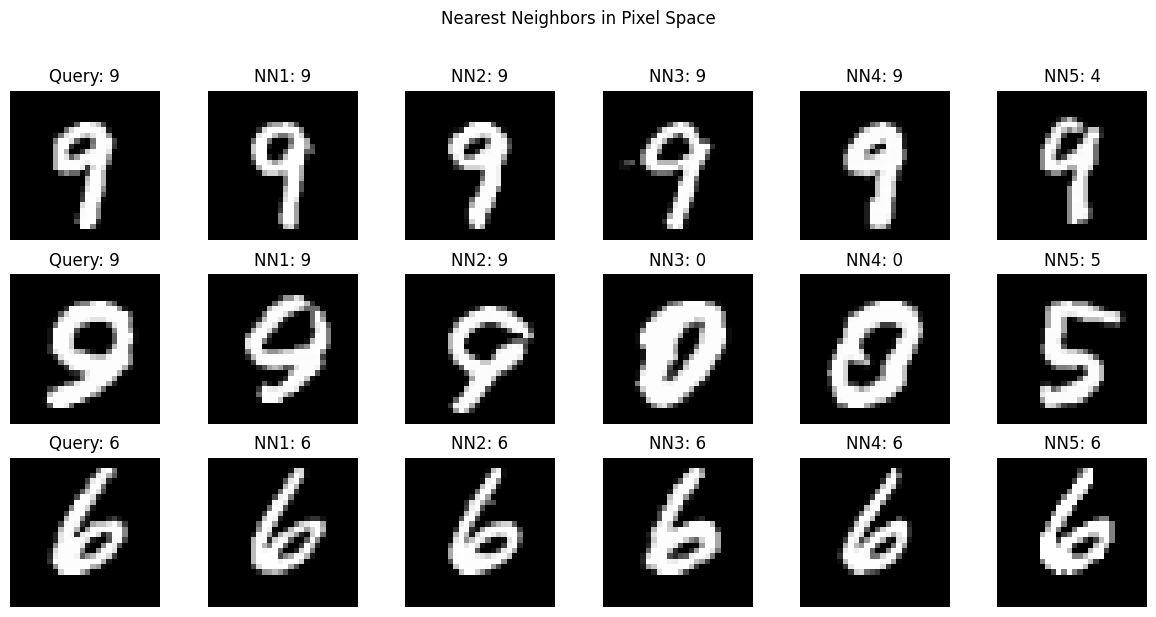

In [9]:
# Flatten images from (n, 28, 28) to (n, 784) for distance calculations
# This reshapes each 28×28 image into a single 784-element vector
# Euclidean distance between vectors reflects overall pixel-wise similarity
x_train_flat = x_train_norm.reshape(x_train_norm.shape[0], -1)
x_test_flat = x_test_norm.reshape(x_test_norm.shape[0], -1)

# Use 30,000 training samples for neighbor search to keep computation manageable
# Using all 60,000 would be slower without substantially changing results
nn_train_size = 30000
# Randomly select 30,000 training samples
train_idx = rng.choice(x_train_flat.shape[0], size=nn_train_size, replace=False)
# Extract the selected training images and their labels
train_subset = x_train_flat[train_idx]
train_labels_subset = y_train[train_idx]

# Select 3 random test images to use as queries
query_idx = rng.choice(x_test_flat.shape[0], size=3, replace=False)
# Extract the query images and their true labels
queries = x_test_flat[query_idx]
query_labels = y_test[query_idx]

# Find the 5 nearest training images for each query
neighbors = []
for q in queries:
    # Compute squared Euclidean distance from query to all training samples
    # (train_subset - q) broadcasts q to subtract from each training sample
    # ** 2 squares each difference
    # .sum(axis=1) sums across all 784 pixels, giving distance per sample
    dists = np.sum((train_subset - q) ** 2, axis=1)
    # Find indices of the 5 samples with smallest distances
    # np.argsort sorts indices by distance value
    # [:5] takes the first 5 (smallest distances)
    nn_idx = np.argsort(dists)[:5]
    neighbors.append(nn_idx)

# Create a grid to display each query and its 5 nearest neighbors
# 3 rows (one per query) × 6 columns (query + 5 neighbors)
fig, axes = plt.subplots(len(queries), 6, figsize=(12, 6))
for i, q_i in enumerate(query_idx):
    # Display the query image in the first column
    ax = axes[i, 0]
    ax.imshow(x_test_norm[q_i], cmap="gray")
    # Show the query's true label
    ax.set_title(f"Query: {query_labels[i]}")
    ax.axis("off")
    # Display each of the 5 nearest neighbors in subsequent columns
    for j, nn_j in enumerate(neighbors[i]):
        ax = axes[i, j + 1]
        # Retrieve the neighbor image from training set using the stored index
        ax.imshow(x_train_norm[train_idx[nn_j]], cmap="gray")
        # Label with neighbor number and its true label
        ax.set_title(f"NN{j + 1}: {train_labels_subset[nn_j]}")
        ax.axis("off")

# Add overall title
fig.suptitle("Nearest Neighbors in Pixel Space", y=1.02)
plt.tight_layout()
plt.show()


Nearest neighbors are usually the same digit as the query, which means digits form clusters in raw pixel space. When a neighbor has a different label, it often looks visually similar, showing where confusion is likely. This is a good sign that distance-based methods like kNN can work, but also a warning that similar digits will still overlap.


## 11) PCA analysis
PCA helps us see how much of the data can be explained in a lower-dimensional space.


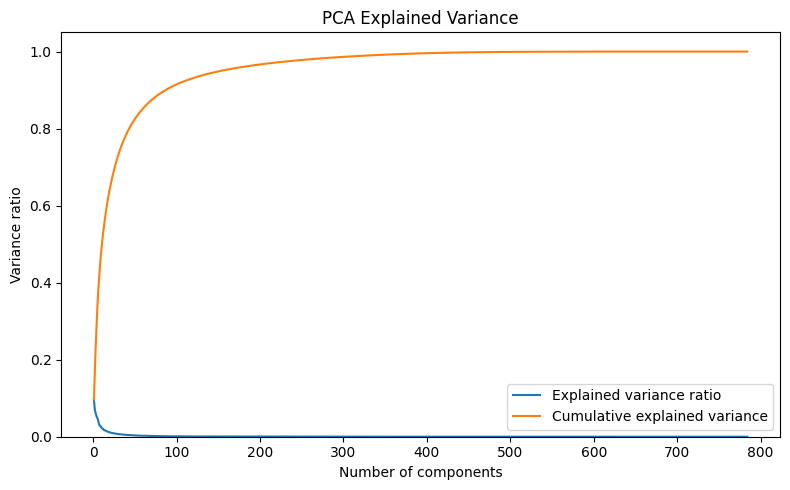

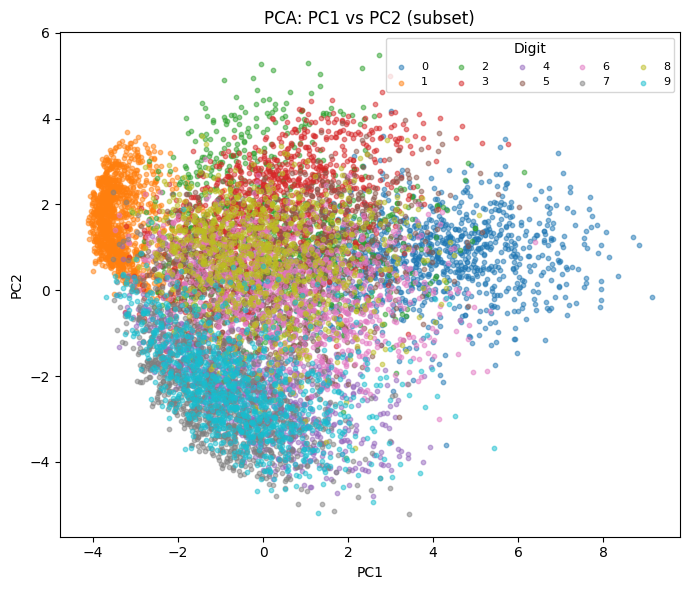

In [10]:
# Fit PCA on up to 30,000 samples to capture global structure efficiently
# Using the full 60,000 would be slower with minimal benefit
# min() ensures we don't try to use more samples than exist
pca_fit_size = min(30000, x_train_flat.shape[0])
# Randomly select samples for PCA fitting
pca_fit_idx = rng.choice(x_train_flat.shape[0], size=pca_fit_size, replace=False)

# Initialize PCA with no component limit (will compute all possible components)
# For 784-dimensional data, this creates up to 784 principal components
pca = PCA()
# Fit PCA to learn the principal components from the selected training data
# PCA finds directions of maximum variance in the 784-dimensional pixel space
pca.fit(x_train_flat[pca_fit_idx])

# Extract how much variance each principal component explains
# explained_variance_ratio_[i] is the fraction of total variance in component i
# Values sum to 1.0 across all components
explained = pca.explained_variance_ratio_
# Calculate cumulative variance: how much variance is explained by first k components
# cumulative[k] tells us the fraction explained by components 0 through k
cumulative = np.cumsum(explained)

# Plot explained variance to see how many components are needed
fig, ax = plt.subplots(figsize=(8, 5))
# Plot individual variance per component
# np.arange creates component numbers: 1, 2, 3, ... (1-indexed for readability)
ax.plot(np.arange(1, len(explained) + 1), explained, label="Explained variance ratio")
# Plot cumulative variance to see total captured by first k components
ax.plot(np.arange(1, len(cumulative) + 1), cumulative, label="Cumulative explained variance")
ax.set_title("PCA Explained Variance")
ax.set_xlabel("Number of components")
# y-axis shows fraction of variance (0 to 1)
ax.set_ylabel("Variance ratio")
# Set y-axis limits: 0 to slightly above 1 for better visualization
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

# Visualize data in the first 2 principal components
# Use up to 10,000 samples for visualization to keep plot readable
scatter_size = min(10000, x_train_flat.shape[0])
scatter_idx = rng.choice(x_train_flat.shape[0], size=scatter_size, replace=False)
# Project selected samples onto the first 2 principal components
# .transform() applies the learned PCA transformation
# [:, :2] selects only the first 2 components (PC1 and PC2)
proj = pca.transform(x_train_flat[scatter_idx])[:, :2]
# Get the corresponding labels for coloring by digit
labels = y_train[scatter_idx]

# Create a scatter plot in the 2D PC space
fig, ax = plt.subplots(figsize=(7, 6))
# Plot each digit class separately to color-code by label
for digit in range(10):
    # Create a boolean mask selecting only samples of this digit
    mask = labels == digit
    # Plot points for this digit
    # proj[mask, 0] extracts PC1 values for this digit
    # proj[mask, 1] extracts PC2 values for this digit
    # s=10 sets small marker size
    # alpha=0.5 makes points semi-transparent to show overlap
    ax.scatter(
        proj[mask, 0],
        proj[mask, 1],
        s=10,
        alpha=0.5,
        label=str(digit),
    )

ax.set_title("PCA: PC1 vs PC2 (subset)")
# PC1 is the direction of maximum variance
ax.set_xlabel("PC1")
# PC2 is the direction of second-highest variance (orthogonal to PC1)
ax.set_ylabel("PC2")
# Show legend with digit labels
# ncol=5 arranges legend in 5 columns for compact display
ax.legend(title="Digit", ncol=5, fontsize=8)
plt.tight_layout()
plt.show()


The explained variance plot shows that the first few components capture a meaningful amount of structure, but many components are still needed to explain most of the variance. The PC1 vs PC2 scatter plot shows partial separation by digit, with noticeable overlap. This means the data has low-dimensional structure, yet classes are not perfectly separable in only two dimensions.


## 12) Hard-case exploration
We look for the most unusual examples within each digit by distance from the class mean.


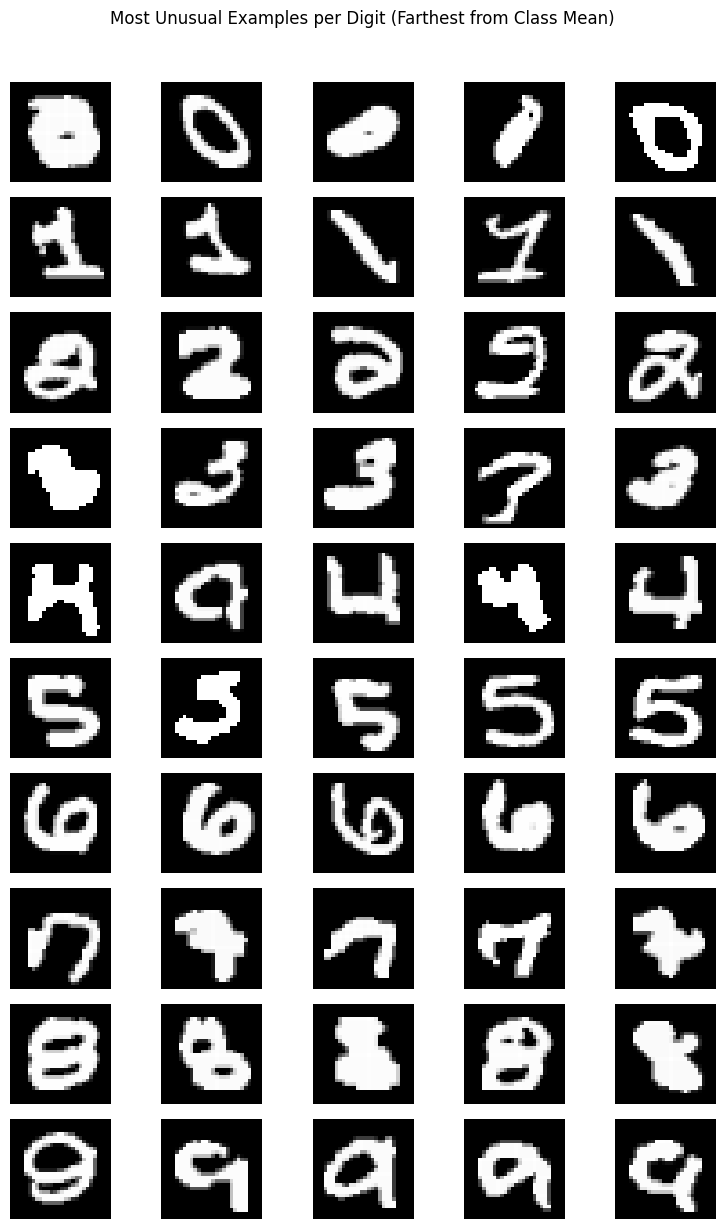

In [11]:
# Compute the mean vector (average image) for each digit class
# This creates a "prototype" representation for each digit
mean_vectors = np.zeros((10, x_train_flat.shape[1]), dtype=np.float32)
for digit in range(10):
    # Calculate mean across all samples of this digit
    # mean_vectors[digit] is a 784-dimensional vector representing the average digit
    mean_vectors[digit] = x_train_flat[y_train == digit].mean(axis=0)

# Number of unusual (outlier) samples to show per digit
n_unusual = 5
# Create a 10×5 grid to display unusual samples for each digit
fig, axes = plt.subplots(10, n_unusual, figsize=(n_unusual * 1.6, 12))
for digit in range(10):
    # Get all indices for this digit
    class_idx = np.where(y_train == digit)[0]
    # Extract the flattened images for this digit class
    class_flat = x_train_flat[class_idx]
    # Calculate Euclidean distance from each sample to the class mean
    # np.linalg.norm computes the L2 norm (Euclidean distance) along axis=1
    # Large distance means the sample is unusual/atypical for its class
    dists = np.linalg.norm(class_flat - mean_vectors[digit], axis=1)
    # Find the 5 samples with largest distances (most unusual)
    # np.argsort sorts indices by distance (smallest to largest)
    # [-n_unusual:] takes the last 5 (largest distances)
    # [::-1] reverses to show most unusual first
    unusual = class_idx[np.argsort(dists)[-n_unusual:]][::-1]
    # Display each unusual sample
    for j, idx in enumerate(unusual):
        ax = axes[digit, j]
        # Show the original (non-flattened) image
        ax.imshow(x_train_norm[idx], cmap="gray")
        ax.axis("off")
        # Add row label for the first column
        if j == 0:
            # rotation=0 keeps label horizontal
            # labelpad=30 adds space between label and image
            # va="center" vertically centers the label
            ax.set_ylabel(f"Digit {digit}", rotation=0, labelpad=30, va="center")

# Add descriptive title
fig.suptitle("Most Unusual Examples per Digit (Farthest from Class Mean)", y=1.02)
plt.tight_layout()
plt.show()


These unusual examples often look messy, incomplete, or styled in a way that does not match the typical class shape. They are likely to be misclassified because they sit far from the average pattern. Studying them helps us set expectations for which digits will be hardest during evaluation.


## 13) EDA conclusions and expected model behavior
Based on the patterns above, we can outline expected performance for common models.

- Logistic regression / linear SVM should perform well because digits are centered, sparse, and have consistent stroke positions that align with linear decision boundaries.
- kNN can work reasonably because many digits cluster in pixel space, but it will struggle when different digits look similar (such as 4 vs 9 or 3 vs 5).
- CNNs should improve results by using spatial locality and translation patterns, which helps them handle small shifts and local stroke variations more effectively than flat pixel models.
